# Limpieza de imagenes del dataset

## Criterios y Reglas de Exclusión de Datos

**Objetivo:** El conjunto de datos contiene un número considerable de imágenes con anomalías que perjudican el rendimiento del modelo. Esto provoca que el entrenamiento se realice con datos irrelevantes o carentes de características significativas, lo que afecta negativamente su capacidad de predicción.

Reglas de Exclusión:
- Filtrado Automático:
    - Imágenes que contengan más de 4 delimitaciones (cajas) o defectos registrados.
- Filtrado Manual:
    - Presencia de texto superpuesto en la imagen.
    - Uso de colores o señalizaciones ajenas a la muestra.
    - Imágenes que presenten elementos distintos a soldaduras válidas.
---

## Librerias

In [1]:
# XYRON Vision - Limpieza de imagenes del dataset
import math
import os
import shutil
from datetime import datetime
from io import BytesIO
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

## Funciones
Las imágenes excluidas no se borran: se mueven con todo y su label a `data_1/_excluidas/<split>/` y cada movimiento se anota en `registro_exclusiones.csv`, así el par imagen/label siempre queda consistente y se puede restaurar.

In [2]:
def obtener_directorios(split):
    """Devuelvo las carpetas de imagenes y etiquetas de un split del dataset."""
    return DIRECTORIO_DATOS / split / "images", DIRECTORIO_DATOS / split / "labels"


def leer_clases(ruta_etiqueta):
    """Leo un archivo YOLO y regreso la lista de ids de clase, una por cada caja anotada."""
    if not ruta_etiqueta.is_file():
        return []
    ids_clase = []
    for linea in ruta_etiqueta.read_text().splitlines():
        partes = linea.split()
        if partes:
            ids_clase.append(int(float(partes[0])))
    return ids_clase


def obtener_origen(nombre_imagen):
    """Obtengo el nombre de la imagen original, quitando el sufijo de aumento que agrega Roboflow (.rf.)."""
    return nombre_imagen.split(".rf.")[0]


def construir_inventario(splits):
    """Recorro los splits y armo un DataFrame con una fila por imagen, su etiqueta y sus cajas."""
    filas = []
    for split in splits:
        dir_imagenes, dir_etiquetas = obtener_directorios(split)
        if not dir_imagenes.is_dir():
            print(f"Aviso: no existe {dir_imagenes}, se omite el split.")
            continue
        for ruta_imagen in sorted(dir_imagenes.iterdir()):
            if ruta_imagen.suffix.lower() not in EXTENSIONES_VALIDAS:
                continue
            ruta_etiqueta = dir_etiquetas / (ruta_imagen.stem + ".txt")
            ids_clase = leer_clases(ruta_etiqueta)
            filas.append({
                "clave": f"{split}/{ruta_imagen.name}",
                "split": split,
                "imagen": ruta_imagen.name,
                "origen": obtener_origen(ruta_imagen.name),
                "n_cajas": len(ids_clase),
                "clases": ids_clase,
                "tiene_etiqueta": ruta_etiqueta.is_file(),
                "ruta_imagen": ruta_imagen,
                "ruta_etiqueta": ruta_etiqueta,
            })
    return pd.DataFrame(filas, columns=COLUMNAS_INVENTARIO)


def resumir_inventario(inventario):
    """Resumo por split cuantas imagenes y cajas hay, y cuantas cajas corresponden a cada clase."""
    agrupado = inventario.groupby("split", sort=False)
    resumen = agrupado.agg(imagenes=("imagen", "count"), cajas=("n_cajas", "sum"))
    resumen["cajas_por_imagen"] = (resumen["cajas"] / resumen["imagenes"]).round(2)
    for indice_clase, nombre_clase in enumerate(CLASES):
        resumen[nombre_clase] = agrupado["clases"].apply(lambda listas: sum(lista.count(indice_clase) for lista in listas))
    return resumen


def mostrar_mosaico(inventario, titulo, n_imagenes, semilla):
    """Muestro un mosaico de 4 columnas con imagenes aleatorias del inventario, en tamano pequeno."""
    if inventario.empty:
        print(f"{titulo}: no hay imagenes para mostrar.")
        return
    muestra = inventario.sample(n=min(n_imagenes, len(inventario)), random_state=semilla)
    n_columnas = 4
    n_filas = math.ceil(len(muestra) / n_columnas)
    figura, ejes = plt.subplots(n_filas, n_columnas, figsize=(10, 2.7 * n_filas), squeeze=False)
    for eje in ejes.ravel():
        eje.axis("off")
    for eje, (_, fila) in zip(ejes.ravel(), muestra.iterrows()):
        with Image.open(fila["ruta_imagen"]) as imagen:
            eje.imshow(imagen.convert("RGB"))
        eje.set_title(f"{fila['split']} | {fila['n_cajas']} cajas", fontsize=8)
    figura.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def ruta_extendida(ruta):
    """En Windows agrego el prefijo de ruta extendida para que las rutas de mas de 260 caracteres no fallen."""
    ruta_absoluta = os.path.abspath(ruta)
    if os.name == "nt" and not ruta_absoluta.startswith(PREFIJO_RUTA_EXTENDIDA):
        return PREFIJO_RUTA_EXTENDIDA + ruta_absoluta
    return ruta_absoluta


def existe_archivo(ruta):
    """Reviso si el archivo existe usando la ruta extendida."""
    return os.path.isfile(ruta_extendida(ruta))


def mover_archivo(ruta_fuente, ruta_destino):
    """Muevo un archivo creando la carpeta destino; si ya hay uno con el mismo nombre lo reemplazo."""
    os.makedirs(ruta_extendida(ruta_destino.parent), exist_ok=True)
    if existe_archivo(ruta_destino):
        os.remove(ruta_extendida(ruta_destino))
    shutil.move(ruta_extendida(ruta_fuente), ruta_extendida(ruta_destino))


def excluir_muestras(seleccion, motivo):
    """Muevo cada imagen seleccionada junto con su etiqueta a la carpeta de excluidas y lo anoto en el registro.

    No borro nada: si algo falla al mover la etiqueta regreso la imagen a su lugar para no dejar pares incompletos.
    """
    registros = []
    try:
        for _, fila in seleccion.iterrows():
            if not fila["ruta_imagen"].is_file():
                continue
            destino_imagen = DIRECTORIO_EXCLUIDAS / fila["split"] / "images" / fila["imagen"]
            destino_etiqueta = DIRECTORIO_EXCLUIDAS / fila["split"] / "labels" / fila["ruta_etiqueta"].name
            try:
                mover_archivo(fila["ruta_imagen"], destino_imagen)
                if fila["ruta_etiqueta"].is_file():
                    mover_archivo(fila["ruta_etiqueta"], destino_etiqueta)
            except OSError as error:
                if existe_archivo(destino_imagen) and not existe_archivo(fila["ruta_imagen"]):
                    mover_archivo(destino_imagen, fila["ruta_imagen"])
                print(f"No se pudo excluir {fila['clave']}: {error}")
                continue
            registros.append({
                "fecha": datetime.now().isoformat(timespec="seconds"),
                "split": fila["split"],
                "imagen": fila["imagen"],
                "etiqueta": fila["ruta_etiqueta"].name,
                "n_cajas": fila["n_cajas"],
                "motivo": motivo,
            })
    finally:
        registro = pd.DataFrame(registros, columns=COLUMNAS_REGISTRO)
        if not registro.empty:
            DIRECTORIO_EXCLUIDAS.mkdir(parents=True, exist_ok=True)
            registro.to_csv(REGISTRO_EXCLUSIONES, mode="a", header=not REGISTRO_EXCLUSIONES.is_file(), index=False, encoding="utf-8")
        print(f"{len(registro)} imagenes (con su etiqueta) movidas a {DIRECTORIO_EXCLUIDAS} | motivo: {motivo}")
    return registro


def restaurar_exclusiones(motivo=None):
    """Regreso a data_1 las imagenes excluidas (todas, o solo las de un motivo) y quito esas filas del registro."""
    if not REGISTRO_EXCLUSIONES.is_file():
        print("No hay exclusiones registradas.")
        return
    registro = pd.read_csv(REGISTRO_EXCLUSIONES, encoding="utf-8")
    por_restaurar = registro if motivo is None else registro[registro["motivo"] == motivo]
    restauradas = []
    for indice, fila in por_restaurar.iterrows():
        dir_imagenes, dir_etiquetas = obtener_directorios(fila["split"])
        excluida_imagen = DIRECTORIO_EXCLUIDAS / fila["split"] / "images" / fila["imagen"]
        excluida_etiqueta = DIRECTORIO_EXCLUIDAS / fila["split"] / "labels" / fila["etiqueta"]
        try:
            if existe_archivo(excluida_imagen):
                mover_archivo(excluida_imagen, dir_imagenes / fila["imagen"])
            if existe_archivo(excluida_etiqueta):
                mover_archivo(excluida_etiqueta, dir_etiquetas / fila["etiqueta"])
            restauradas.append(indice)
        except OSError as error:
            print(f"No se pudo restaurar {fila['split']}/{fila['imagen']}: {error}")
    registro.drop(index=restauradas).to_csv(REGISTRO_EXCLUSIONES, index=False, encoding="utf-8")
    print(f"{len(restauradas)} imagenes restauradas a {DIRECTORIO_DATOS}")


def verificar_consistencia(splits):
    """Reviso que en cada split toda imagen tenga su etiqueta y que no queden etiquetas huerfanas."""
    todo_correcto = True
    for split in splits:
        dir_imagenes, dir_etiquetas = obtener_directorios(split)
        if not dir_imagenes.is_dir() or not dir_etiquetas.is_dir():
            print(f"{split}: falta la carpeta de imagenes o de etiquetas")
            todo_correcto = False
            continue
        nombres_imagenes = {ruta.stem for ruta in dir_imagenes.iterdir() if ruta.suffix.lower() in EXTENSIONES_VALIDAS}
        nombres_etiquetas = {ruta.stem for ruta in dir_etiquetas.glob("*.txt")}
        sin_etiqueta = nombres_imagenes - nombres_etiquetas
        huerfanas = nombres_etiquetas - nombres_imagenes
        print(f"{split}: {len(nombres_imagenes)} imagenes | {len(nombres_etiquetas)} etiquetas | "
              f"sin etiqueta: {len(sin_etiqueta)} | etiquetas huerfanas: {len(huerfanas)}")
        todo_correcto = todo_correcto and not sin_etiqueta and not huerfanas
    return todo_correcto


class RevisorManual:
    """Creo una galeria paginada con ipywidgets para marcar imagenes y excluirlas junto con su etiqueta.

    Guardo las marcas en un CSV en cada clic, asi no se pierde la revision si se reinicia el kernel.
    """

    def __init__(self, splits, por_pagina, n_columnas, tamano_miniatura):
        self.splits = list(splits)
        self.por_pagina = por_pagina
        self.tamano_miniatura = tamano_miniatura
        self.inventario = construir_inventario(self.splits)
        self.marcadas = self.cargar_marcas()
        self.miniaturas = {}
        self.pagina = 0

        self.selector_split = widgets.Dropdown(options=["todos"] + self.splits, value="todos", description="Split:")
        self.boton_anterior = widgets.Button(description="Anterior", icon="arrow-left")
        self.boton_siguiente = widgets.Button(description="Siguiente", icon="arrow-right")
        self.texto_pagina = widgets.HTML()
        self.texto_marcadas = widgets.HTML()
        self.boton_desmarcar = widgets.Button(description="Desmarcar todo", icon="undo")
        self.confirmacion = widgets.Checkbox(value=False, description="Confirmo mover las imágenes marcadas", indent=False)
        self.boton_aplicar = widgets.Button(description="Aplicar exclusión", button_style="danger", icon="trash")
        self.galeria = widgets.GridBox(layout=widgets.Layout(grid_template_columns=f"repeat({n_columnas}, {tamano_miniatura + 10}px)", grid_gap="8px"))
        self.salida = widgets.Output()

        self.selector_split.observe(self.cambiar_split, names="value")
        self.boton_anterior.on_click(lambda _: self.cambiar_pagina(-1))
        self.boton_siguiente.on_click(lambda _: self.cambiar_pagina(1))
        self.boton_desmarcar.on_click(self.desmarcar_todo)
        self.boton_aplicar.on_click(self.aplicar_exclusion)

        self.contenedor = widgets.VBox([
            widgets.HBox([self.selector_split, self.boton_anterior, self.texto_pagina, self.boton_siguiente]),
            self.galeria,
            widgets.HBox([self.texto_marcadas, self.boton_desmarcar]),
            widgets.HBox([self.confirmacion, self.boton_aplicar]),
            self.salida,
        ])
        self.actualizar_galeria()

    def cargar_marcas(self):
        """Recupero las marcas guardadas que todavia correspondan a imagenes presentes en el dataset."""
        if not ARCHIVO_MARCAS.is_file():
            return set()
        guardadas = set(pd.read_csv(ARCHIVO_MARCAS, encoding="utf-8")["clave"])
        return guardadas & set(self.inventario["clave"])

    def guardar_marcas(self):
        """Escribo en disco las claves marcadas para excluir."""
        ARCHIVO_MARCAS.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame({"clave": sorted(self.marcadas)}).to_csv(ARCHIVO_MARCAS, index=False, encoding="utf-8")

    def vista_actual(self):
        """Filtro el inventario segun el split elegido en el selector."""
        if self.selector_split.value == "todos":
            return self.inventario
        return self.inventario[self.inventario["split"] == self.selector_split.value]

    def total_paginas(self):
        """Calculo cuantas paginas tiene la vista actual (minimo una)."""
        return max(1, math.ceil(len(self.vista_actual()) / self.por_pagina))

    def crear_miniatura(self, clave, ruta_imagen):
        """Genero (y guardo en cache) una miniatura JPEG de la imagen para mostrarla en la galeria."""
        if clave not in self.miniaturas:
            with Image.open(ruta_imagen) as imagen:
                miniatura = imagen.convert("RGB")
            miniatura.thumbnail((self.tamano_miniatura, self.tamano_miniatura))
            bufer = BytesIO()
            miniatura.save(bufer, format="JPEG", quality=85)
            self.miniaturas[clave] = bufer.getvalue()
        return self.miniaturas[clave]

    def crear_tarjeta(self, fila):
        """Armo la tarjeta de una imagen: miniatura, datos, boton para marcarla y boton para verla en grande."""
        clave = fila["clave"]
        marcada = clave in self.marcadas
        miniatura = widgets.Image(value=self.crear_miniatura(clave, fila["ruta_imagen"]), format="jpeg",
                                  layout=widgets.Layout(width=f"{self.tamano_miniatura}px"))
        datos = widgets.HTML(f"<small>{fila['split']} | {fila['n_cajas']} cajas<br>{fila['imagen'][:26]}</small>")
        boton_marca = widgets.ToggleButton(value=marcada, description="Excluir", icon="trash",
                                           button_style="danger" if marcada else "",
                                           layout=widgets.Layout(width="95px"))
        boton_ver = widgets.Button(description="Ver", icon="search", layout=widgets.Layout(width="70px"))
        boton_marca.observe(lambda cambio: self.alternar_marca(cambio, clave), names="value")
        boton_ver.on_click(lambda _: self.ver_imagen(fila))
        return widgets.VBox([miniatura, datos, widgets.HBox([boton_marca, boton_ver])])

    def alternar_marca(self, cambio, clave):
        """Agrego o quito la imagen del conjunto de marcadas y guardo el cambio."""
        if cambio["new"]:
            self.marcadas.add(clave)
        else:
            self.marcadas.discard(clave)
        cambio["owner"].button_style = "danger" if cambio["new"] else ""
        self.guardar_marcas()
        self.actualizar_contador()

    def ver_imagen(self, fila):
        """Muestro la imagen a tamano completo en el area de salida para revisar detalles como texto pequeno."""
        with self.salida:
            self.salida.clear_output()
            print(fila["clave"])
            display(widgets.Image(value=fila["ruta_imagen"].read_bytes(), format="jpeg", layout=widgets.Layout(width="640px")))

    def actualizar_contador(self):
        """Actualizo el texto con el numero de imagenes marcadas."""
        self.texto_marcadas.value = f"<b>Marcadas para excluir: {len(self.marcadas)}</b>"

    def actualizar_galeria(self):
        """Dibujo las tarjetas de la pagina actual y actualizo los controles de navegacion."""
        vista = self.vista_actual()
        self.pagina = min(max(self.pagina, 0), self.total_paginas() - 1)
        inicio = self.pagina * self.por_pagina
        pagina_actual = vista.iloc[inicio:inicio + self.por_pagina]
        self.galeria.children = [self.crear_tarjeta(fila) for _, fila in pagina_actual.iterrows()]
        self.texto_pagina.value = f"&nbsp;Página {self.pagina + 1} de {self.total_paginas()} ({len(vista)} imágenes)&nbsp;"
        self.boton_anterior.disabled = self.pagina == 0
        self.boton_siguiente.disabled = self.pagina >= self.total_paginas() - 1
        self.actualizar_contador()

    def cambiar_pagina(self, desplazamiento):
        """Avanzo o retrocedo una pagina."""
        self.pagina += desplazamiento
        self.actualizar_galeria()

    def cambiar_split(self, _):
        """Reinicio la paginacion cuando se elige otro split."""
        self.pagina = 0
        self.actualizar_galeria()

    def desmarcar_todo(self, _):
        """Quito todas las marcas."""
        self.marcadas.clear()
        self.guardar_marcas()
        self.actualizar_galeria()

    def aplicar_exclusion(self, _):
        """Muevo las imagenes marcadas (y sus variantes si asi se configuro) a la carpeta de excluidas."""
        with self.salida:
            self.salida.clear_output()
            if not self.marcadas:
                print("No hay imágenes marcadas.")
                return
            if not self.confirmacion.value:
                print("Marca la casilla de confirmación antes de aplicar la exclusión.")
                return
            seleccion = self.inventario[self.inventario["clave"].isin(self.marcadas)]
            if INCLUIR_VARIANTES:
                seleccion = self.inventario[self.inventario["origen"].isin(seleccion["origen"])]
                n_variantes = len(seleccion) - len(self.marcadas)
                if n_variantes > 0:
                    print(f"Se agregan {n_variantes} variantes (misma imagen original) de las imágenes marcadas.")
            excluir_muestras(seleccion, "manual")
            self.inventario = construir_inventario(self.splits)
            self.marcadas &= set(self.inventario["clave"])
            self.guardar_marcas()
            self.confirmacion.value = False
            self.actualizar_galeria()

    def mostrar(self):
        """Despliego la interfaz de revision en el notebook."""
        display(self.contenedor)

## Parámetros de configuración

In [3]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
DIRECTORIO_DATOS = BASE_DIR / "data_1"
DIRECTORIO_EXCLUIDAS = DIRECTORIO_DATOS / "_excluidas"
REGISTRO_EXCLUSIONES = DIRECTORIO_EXCLUIDAS / "registro_exclusiones.csv"
ARCHIVO_MARCAS = DIRECTORIO_EXCLUIDAS / "marcas_manuales.csv"

SPLITS = ["train", "valid", "test"]
CLASES = ["Bad Weld", "Good Weld", "Defect"]
EXTENSIONES_VALIDAS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
PREFIJO_RUTA_EXTENDIDA = "\\\\?\\"
COLUMNAS_INVENTARIO = ["clave", "split", "imagen", "origen", "n_cajas", "clases", "tiene_etiqueta", "ruta_imagen", "ruta_etiqueta"]
COLUMNAS_REGISTRO = ["fecha", "split", "imagen", "etiqueta", "n_cajas", "motivo"]

MAX_CAJAS = 4
APLICAR_LIMPIEZA_AUTOMATICA = True
INCLUIR_VARIANTES = True

N_MOSAICO = 16
IMAGENES_POR_PAGINA = 24
COLUMNAS_REVISION = 6
TAMANO_MINIATURA = 200
SEMILLA = 42

RESTAURAR_EXCLUSIONES = False
MOTIVO_A_RESTAURAR = None

assert DIRECTORIO_DATOS.is_dir(), f"No se encontró la carpeta de datos: {DIRECTORIO_DATOS}"
print("Datos     :", DIRECTORIO_DATOS)
print("Excluidas :", DIRECTORIO_EXCLUIDAS)
print("Splits    :", SPLITS)

Datos     : c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION\data_1
Excluidas : c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION\data_1\_excluidas
Splits    : ['train', 'valid', 'test']


## Muestra de imagens
Se muestra un mosaico de 16 imagenes aleatorias en pequeño para ver una muesta de los datos

Imágenes encontradas: 1084


,imagenes,cajas,cajas_por_imagen,Bad Weld,Good Weld,Defect
split,,,,,,
train,834,3126,3.75,732,1109,1285
valid,176,573,3.26,127,253,193
test,74,209,2.82,67,76,66


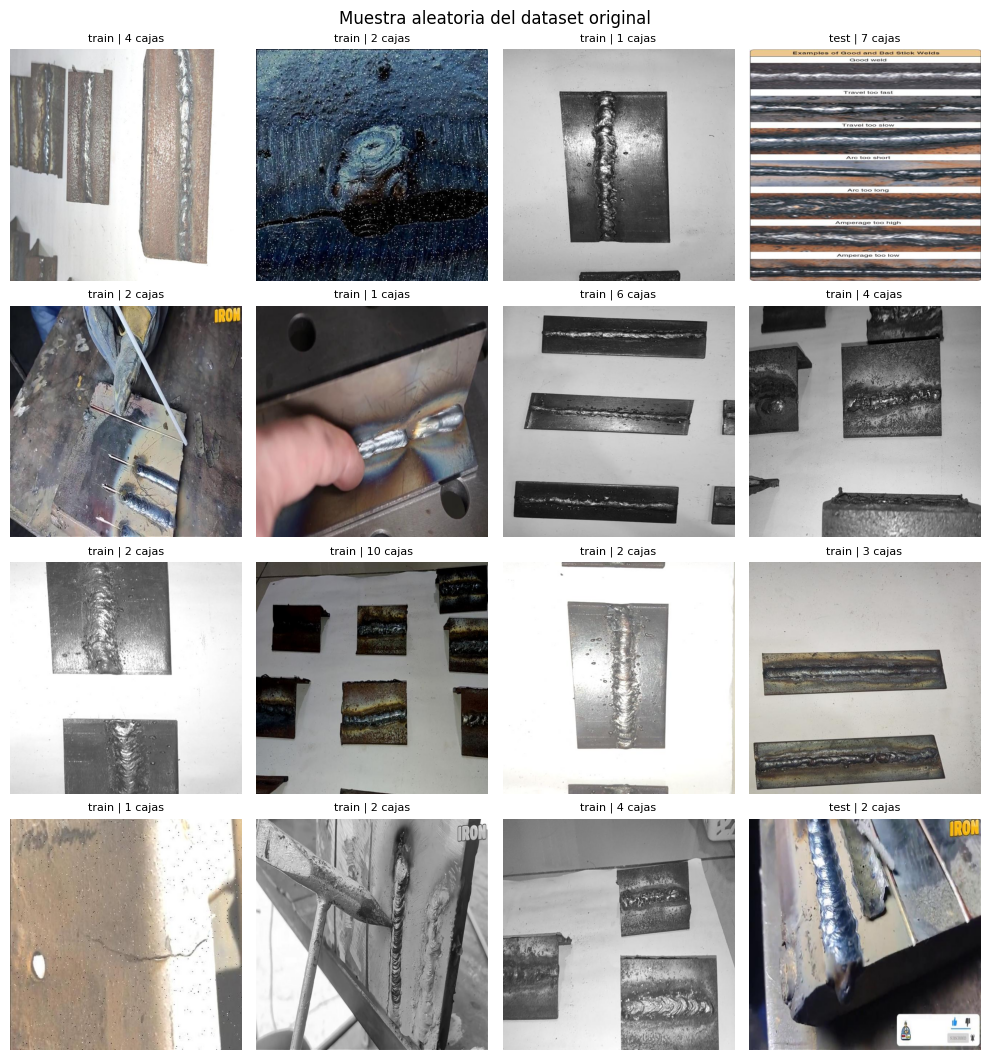

In [4]:
inventario_inicial = construir_inventario(SPLITS)
print(f"Imágenes encontradas: {len(inventario_inicial)}")
display(resumir_inventario(inventario_inicial))
mostrar_mosaico(inventario_inicial, "Muestra aleatoria del dataset original", N_MOSAICO, SEMILLA)

## Limpieza automatica

Imágenes con más de 4 cajas: 305 de 1084


,imagenes,a_excluir
split,,
train,834,255
valid,176,38
test,74,12


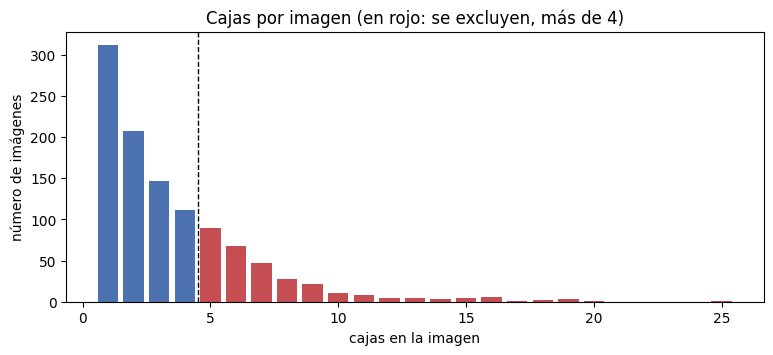

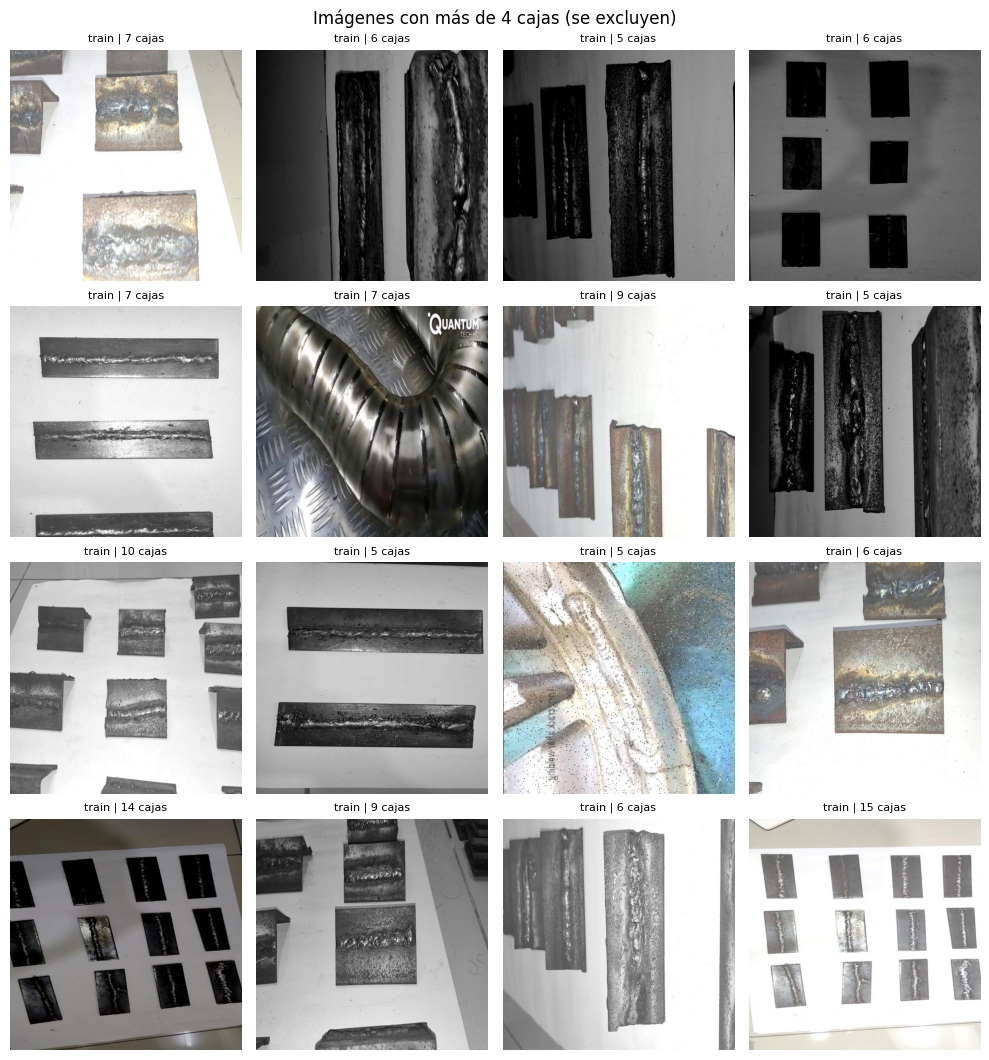

305 imagenes (con su etiqueta) movidas a c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION\data_1\_excluidas | motivo: automatica: mas de 4 cajas


In [5]:
inventario = construir_inventario(SPLITS)
candidatas_automaticas = inventario[inventario["n_cajas"] > MAX_CAJAS]

print(f"Imágenes con más de {MAX_CAJAS} cajas: {len(candidatas_automaticas)} de {len(inventario)}")
display(pd.DataFrame({
    "imagenes": inventario.groupby("split", sort=False)["imagen"].count(),
    "a_excluir": candidatas_automaticas.groupby("split", sort=False)["imagen"].count(),
}).fillna(0).astype(int))

frecuencia_cajas = inventario["n_cajas"].value_counts().sort_index()
plt.figure(figsize=(9, 3.5))
plt.bar(frecuencia_cajas.index, frecuencia_cajas.values,
        color=["#C44E52" if n_cajas > MAX_CAJAS else "#4C72B0" for n_cajas in frecuencia_cajas.index])
plt.axvline(MAX_CAJAS + 0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("cajas en la imagen")
plt.ylabel("número de imágenes")
plt.title(f"Cajas por imagen (en rojo: se excluyen, más de {MAX_CAJAS})")
plt.show()

mostrar_mosaico(candidatas_automaticas, f"Imágenes con más de {MAX_CAJAS} cajas (se excluyen)", N_MOSAICO, SEMILLA)

if APLICAR_LIMPIEZA_AUTOMATICA:
    excluir_muestras(candidatas_automaticas, f"automatica: mas de {MAX_CAJAS} cajas")
else:
    print("APLICAR_LIMPIEZA_AUTOMATICA = False: no se movió ningún archivo.")

## Limpieza Manual

### Texto, Colores y distintos
Utilizando ipywidgets, poder seleccionar cuales imagene se eliminan con todo y label, evitando tener inconsistencia

In [ ]:
revisor = RevisorManual(SPLITS, IMAGENES_POR_PAGINA, COLUMNAS_REVISION, TAMANO_MINIATURA)
revisor.mostrar()

## Muestra de imagens limpiados
Se muestra un mosaico de 16 imagenes aleatorias en pequeño para ver una muesta de los datos cambiados

Imágenes restantes: 732


,imagenes,cajas,cajas_por_imagen,Bad Weld,Good Weld,Defect
split,,,,,,
train,543,1141,2.10,253,466,422
valid,133,286,2.15,61,137,88
test,56,105,1.88,32,45,28


Imágenes excluidas en total: 352


split,test,train,valid
motivo,,,
automatica: mas de 4 cajas,12,255,38
manual,6,36,5


train: 543 imagenes | 543 etiquetas | sin etiqueta: 0 | etiquetas huerfanas: 0
valid: 133 imagenes | 133 etiquetas | sin etiqueta: 0 | etiquetas huerfanas: 0
test: 56 imagenes | 56 etiquetas | sin etiqueta: 0 | etiquetas huerfanas: 0


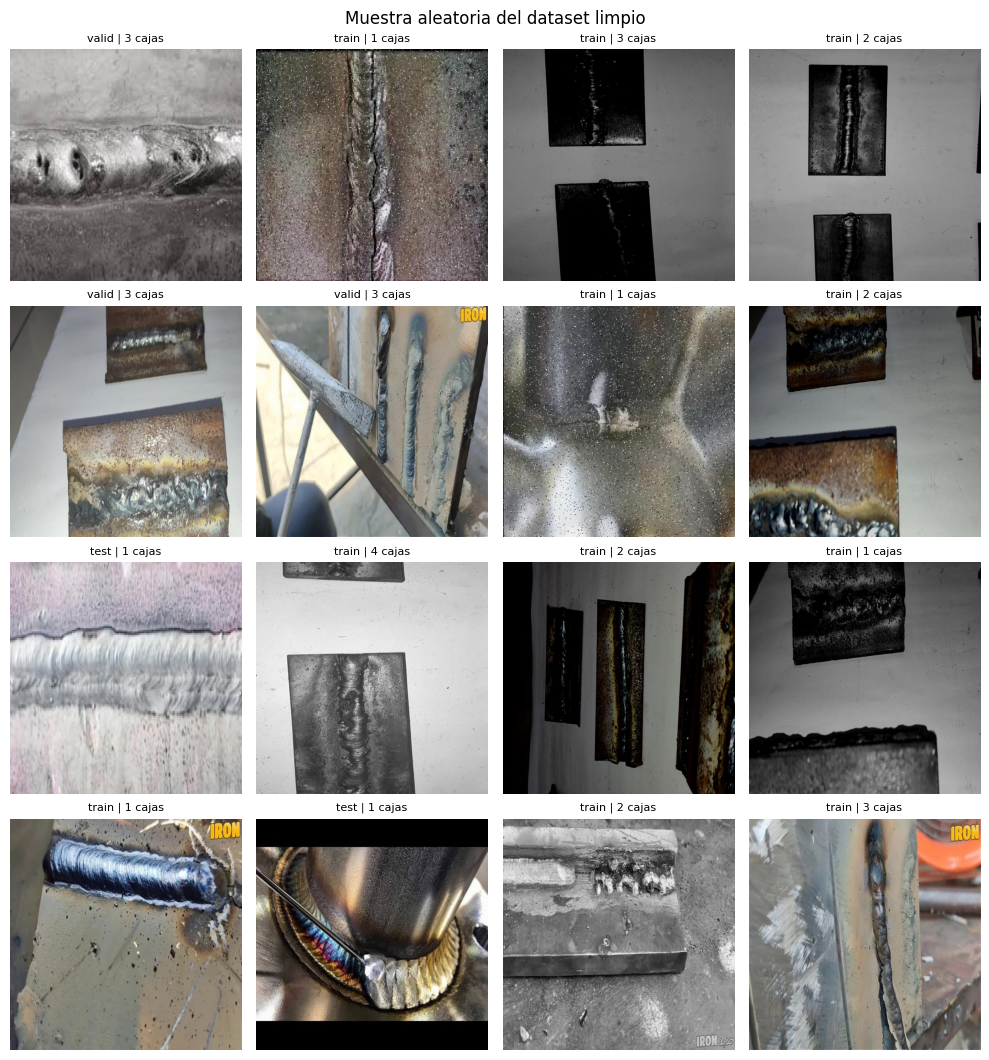

In [7]:
inventario_limpio = construir_inventario(SPLITS)
print(f"Imágenes restantes: {len(inventario_limpio)}")
display(resumir_inventario(inventario_limpio))

if REGISTRO_EXCLUSIONES.is_file():
    registro_exclusiones = pd.read_csv(REGISTRO_EXCLUSIONES, encoding="utf-8")
    print(f"Imágenes excluidas en total: {len(registro_exclusiones)}")
    if not registro_exclusiones.empty:
        display(registro_exclusiones.groupby(["motivo", "split"]).size().unstack(fill_value=0))

assert verificar_consistencia(SPLITS), "Hay imágenes sin etiqueta o etiquetas huérfanas (ver arriba)."
mostrar_mosaico(inventario_limpio, "Muestra aleatoria del dataset limpio", N_MOSAICO, SEMILLA)

## Restaurar exclusiones
Regresa a `data_1` las imágenes excluidas. Para usarlo cambiar `RESTAURAR_EXCLUSIONES = True` (y opcionalmente `MOTIVO_A_RESTAURAR`, por ejemplo `"manual"`) en los parámetros y volver a ejecutar esa celda y esta.

In [ ]:
'''
if RESTAURAR_EXCLUSIONES:
    restaurar_exclusiones(MOTIVO_A_RESTAURAR)
    verificar_consistencia(SPLITS)
else:
    print("RESTAURAR_EXCLUSIONES = False: no se restauró nada.")
'''